# Spatial and cell type-specific gene expression trajectories with age

This notebook contains code for clustering of gene expression trajectories and annotation into discrete trajectory groups.

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import anndata as ad
import os
from scipy.stats import pearsonr, spearmanr, mannwhitneyu, ttest_ind, hypergeom
import matplotlib.colors as mcolors

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import pickle
import gseapy as gp

import umap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import make_interp_spline
from scipy.interpolate import splrep, BSpline
from scipy.signal import savgol_filter

os.chdir("/labs/abrunet1/Eric/MERFISH")

## Compute mean vectors for celltype x region by age

In [13]:
adata = sc.read_h5ad("data/integrated_aging_coronal_celltyped_regioned_raw.h5ad")
adata = adata[(adata.obs.clusters!="1")&(adata.obs.mouse_id!="89")&(adata.obs.mouse_id!="67")].copy()

In [4]:
sc.pp.normalize_total(adata) # normalize for each cell

In [5]:
# Extract mean aging expression trajectories for gene-celltype-region combinations

labels = []
age_expn_vectors = []

ages = np.unique(adata.obs.age)

for ct in np.unique(adata.obs.celltype):
    for region in np.unique(adata.obs.region):
        sub_adata = adata[(adata.obs.celltype==ct)&(adata.obs.region==region)].copy()
        if len(np.unique(sub_adata.obs.age)) == len(np.unique(adata.obs.age)):
            for gene in adata.var_names:
                labels.append(f"{gene}_{ct}_{region}")
                age_expn_vector = []
                for age in ages:
                    age_expn_vector.append(float(np.mean(sub_adata[sub_adata.obs.age==age,gene].X)))
                age_expn_vectors.append(age_expn_vector)

In [6]:
# save results as dataframe

df = pd.DataFrame(np.vstack(age_expn_vectors).T, columns=labels)
df["age"] = ages
df.to_csv("results/gene_trajectory/gene_celltype_region_mean_age_expression_raw.csv", index=None)

## Perform clustering on age expression vectors

In [3]:
# load results

df = pd.read_csv("results/gene_trajectory/gene_celltype_region_mean_age_expression_raw.csv")

In [5]:
# extract matrix
ages = df['age'].values.copy()
df.drop(columns='age')
age_expn_matrix = df.values

# standardize so clustering done on trends
age_expn_matrix = StandardScaler().fit_transform(age_expn_matrix)
age_expn_matrix = age_expn_matrix.T

In [6]:
# visualization
reducer = umap.UMAP()
embedding = reducer.fit_transform(age_expn_matrix)

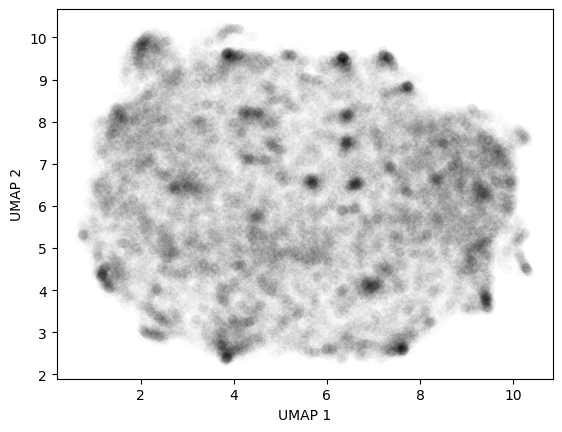

In [7]:
plt.scatter(embedding[:,0], embedding[:,1], c='k', alpha=0.01)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [8]:
# clustering (K-means)
kmeans = KMeans(n_clusters=9, random_state=444, n_init="auto").fit(age_expn_matrix)

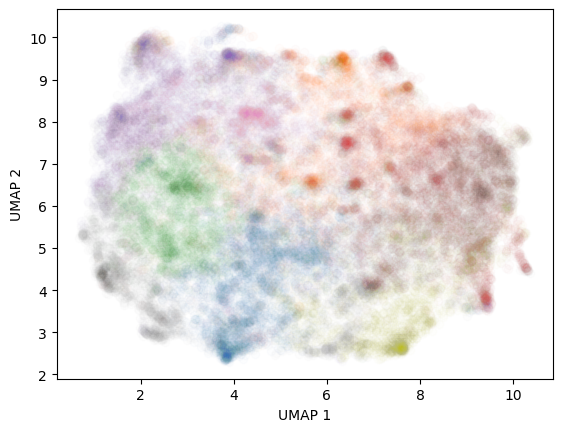

In [9]:
for label in np.unique(kmeans.labels_):
    plt.scatter(embedding[kmeans.labels_==label,0],
                embedding[kmeans.labels_==label,1],
                alpha=0.01)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [10]:
# Get average Pearson correlations to help with cluster annotations

colors = ['tab:blue', 'tab:orange', 'tab:green',
          'tab:red', 'tab:purple', 'tab:brown']

avg_pearsons = []

for li, label in enumerate(np.unique(kmeans.labels_)):
    sub_age_expn_matrix = age_expn_matrix[kmeans.labels_==label,:]
    pearsons = []
    for i in range(sub_age_expn_matrix.shape[0]):
        r,p = pearsonr(ages,sub_age_expn_matrix[i,:])
        pearsons.append(r)
    avg_pearsons.append(np.nanmean(pearsons))

/home/edsun/.conda/envs/merfish/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [11]:
print (avg_pearsons)

[0.04820053738287331, -0.36410675618343685, -0.22457206885848127, 0.011937623240640936, -0.004360237445035462, 0.021272050643485117, -0.060544540006877694, 0.4015400751884558, 0.21392875557788893]


## Final Figures

In [15]:
# For combined data -- 67/87 removed and cluster1 removed
colors = ['firebrick', 'lightcoral', 'tan',
          'goldenrod', 'grey', 'olive', 
          'darkkhaki', 'cornflowerblue', 'royalblue'] # olive, darkkhaki
labels = [7,8,0,
          5,3,4,
          6,2,1]

group_names = ["Increasing Late", "Increasing Gradual", "Midlife Trough",
               "Early Peak","Midlife Peak","Late Peak",
               "Midlife Decrease","Decreasing Early", "Decreasing Gradual"]

group_names_detailed = [f"{group_names[ii]}\n({np.sum(kmeans.labels_==labels[ii])})" for ii in range(len(group_names))]

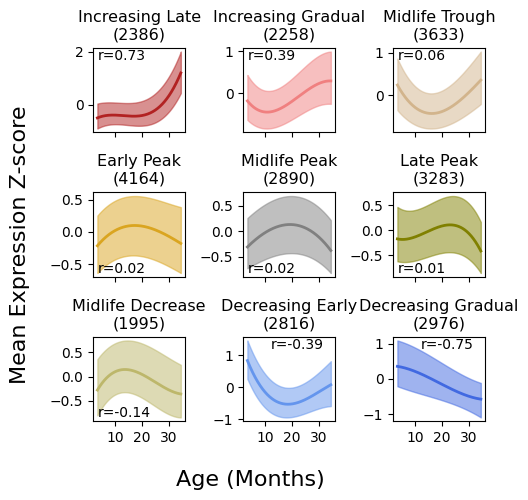

In [14]:
### make plot
nrows = 3
ncols = 3

pos_dict = {"br": (0.3, 0.05, 0.05),
            "bl": (0.05, 0.05, 0.05),
            "tr": (0.3, 0.85, 0.825),
            "tl": (0.05, 0.85, 0.825)}
corner_for_annot = ["tl", "tl", "tl",
                    "bl", "bl", "bl",
                    "bl", "tr", "tr"]

fig, axs = plt.subplots(nrows, ncols, figsize=(5,5), sharex=True, sharey=False)

counter = 0
for i in range(nrows):
    for j in range(ncols):
        
        lab = labels[counter]
        
        # subset into cluster
        sub_age_expn_matrix = age_expn_matrix[kmeans.labels_==lab,:]
        
        # compute mean and spread for each cluster
        median_expn = np.median(sub_age_expn_matrix,axis=0)
        spread_expn_upper = np.percentile(sub_age_expn_matrix,75,axis=0)
        spread_expn_lower = np.percentile(sub_age_expn_matrix,25,axis=0)
        
        # smoothen mean trajectories
        ages_fine = np.linspace(np.min(ages), np.max(ages), 500)
        
        smoother = BSpline(*splrep(ages, median_expn, s=len(ages)))
        median_expn_smooth = smoother(ages_fine)
        
        smoother = BSpline(*splrep(ages, spread_expn_upper, s=len(ages)))
        spread_expn_upper_smooth= smoother(ages_fine)
        
        smoother = BSpline(*splrep(ages, spread_expn_lower, s=len(ages)))
        spread_expn_lower_smooth= smoother(ages_fine)
        
        # plot mean and spread
        axs[i,j].plot(ages_fine, median_expn_smooth, color=colors[counter], linewidth=2)
        axs[i,j].fill_between(ages_fine, spread_expn_lower_smooth, spread_expn_upper_smooth, color=colors[counter], alpha=0.5)
        
        r,p = pearsonr(ages, median_expn)
        x, y1, y2 = pos_dict[corner_for_annot[j+i*ncols]]
        axs[i,j].text(x, y1, "r="+str(round(r,2)), transform=axs[i,j].transAxes, 
            size=10)
        
        axs[i,j].set_title(group_names_detailed[counter], fontsize=11.5)
        
        counter += 1

for a in axs.flatten():
    a.tick_params(axis='both', which='major', labelsize=10)
    a.tick_params(axis='both', which='minor', labelsize=10)
        
# make figure
fig.supxlabel("Age (Months)", fontsize=16)
fig.supylabel("Mean Expression Z-score", fontsize=16)
plt.tight_layout()
plt.savefig("plots/gene_trajectory/paneled_mean_trajectories_k9_p5smoothed.pdf", bbox_inches='tight')
plt.show()

In [28]:
gene = "Cdkn2a" # Increasing (Ifi27) -- Decreasing (Mki67, Cat, Sod2)
# -- Region-variable (Tert, Tgfb1, Igf1, Cdkn2a)

label_arr = np.empty((len(pd.unique(adata.obs.celltype).sort_values()),len(np.unique(adata.obs.region))))

for ci, ct in enumerate(pd.unique(adata.obs.celltype).sort_values()):
    for ri, region in enumerate(np.unique(adata.obs.region)):
        if f"{gene}_{ct}_{region}" in df.columns:
            col_idx = np.where(df.columns==f"{gene}_{ct}_{region}")[0][0]
            label_arr[ci,ri] = labels.index(kmeans.labels_[col_idx])
        else:
            label_arr[ci,ri] = np.nan

In [29]:
# build array for heatmap
color_arr = np.empty_like(label_arr, dtype="<U100")
name_arr = np.empty_like(label_arr, dtype="<U100")

for i in range(label_arr.shape[0]):
    for j in range(label_arr.shape[1]):
        if not np.isnan(label_arr[i,j]):
            color_arr[i,j] = colors[int(label_arr[i,j])]
            name_arr[i,j] = group_names[int(label_arr[i,j])]
        else:
            color_arr[i,j] = "w"
            name_arr[i,j] = ""

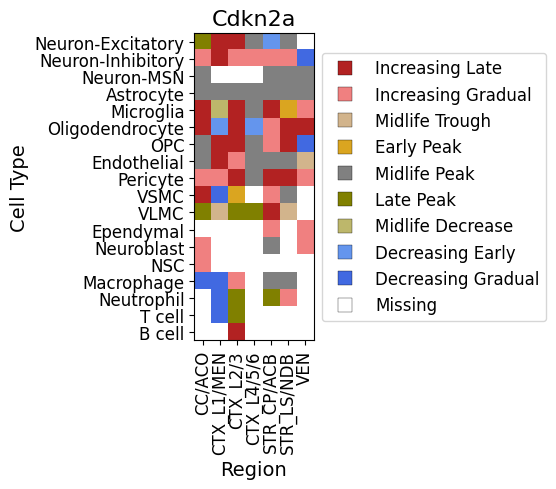

In [30]:
# Create a colormap dictionary to map colors to numerical values
colormap = {}
for ci, col in enumerate(colors+["w"]):
    colormap[col] = ci
    
# Convert color_arr to numerical values based on colormap
numerical_color_arr = np.vectorize(colormap.get)(color_arr)

# Create a custom colormap based on the colors in color_arr
color_list = list(colormap.keys())
custom_cmap = mcolors.ListedColormap(color_list)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(7,5))

# Create the heatmap plot
heatmap = ax.imshow(numerical_color_arr, cmap=custom_cmap)

# Set the tick labels and positions for x-axis
ax.set_xticks(np.arange(len(name_arr[0])))
ax.set_xticklabels(np.unique(adata.obs.region), rotation=90, fontsize=12)
ax.set_xlabel('Region', fontsize=14)

# Set the tick labels and positions for y-axis
ax.set_yticks(np.arange(len(name_arr)))
ax.set_yticklabels(pd.unique(adata.obs.celltype).sort_values(), fontsize=12)
ax.set_ylabel('Cell Type', fontsize=14)

# Create a legend for the color labels
legend_labels = group_names+["Missing"]
legend_elements = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color, label=label, markersize=10, markeredgewidth=0.25, markeredgecolor='k', linewidth=0)
                   for color, label in zip(color_list, legend_labels)]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.title(f"{gene}", fontsize=16)

plt.tight_layout()
plt.savefig(f"plots/gene_trajectory/heatmap_trajclusters_{gene}.pdf", bbox_inches='tight')
plt.show()